In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from fredapi import Fred

FRED_KEY = "9e67dd28060675ec071dfaa9f650840f"
fred = Fred(api_key=FRED_KEY)
print("Ready.")

Ready.


In [2]:
series = {
    'Bank credit':     'TOTBKCR',
    'Housing starts':  'HOUST',
    'Credit spread':   'BAMLH0A0HYM2',
    'Consumer credit': 'TOTALSL',
    'Fed funds rate':  'FEDFUNDS',
}
data = {}
for name, code in series.items():
    try:
        s = fred.get_series(code, observation_start='2000-01-01',
                                  observation_end='2012-01-01')
        print(f"{name}: {len(s)} obs, index type={type(s.index).__name__}")
        if len(s) > 0:
            print(f"  first date: {s.index[0]}, last date: {s.index[-1]}")
            data[name] = s
        else:
            print(f"  WARNING: empty series returned")
    except Exception as e:
        print(f"FAILED {name}: {e}")

print(f"\nSuccessfully loaded: {list(data.keys())}")

Bank credit: 626 obs, index type=DatetimeIndex
  first date: 2000-01-05 00:00:00, last date: 2011-12-28 00:00:00
Housing starts: 145 obs, index type=DatetimeIndex
  first date: 2000-01-01 00:00:00, last date: 2012-01-01 00:00:00
Credit spread: 0 obs, index type=RangeIndex
Consumer credit: 145 obs, index type=DatetimeIndex
  first date: 2000-01-01 00:00:00, last date: 2012-01-01 00:00:00
Fed funds rate: 145 obs, index type=DatetimeIndex
  first date: 2000-01-01 00:00:00, last date: 2012-01-01 00:00:00

Successfully loaded: ['Bank credit', 'Housing starts', 'Consumer credit', 'Fed funds rate']


In [3]:
def critical_slowing_down(series, window=24):
    """
    Compute early warning signals for a time series.
    Rising variance + rising autocorrelation = system approaching tipping point.
    Proven mathematically for any dynamical system near a bifurcation.
    """
    # Resample to monthly so all series align
    monthly = series.resample('MS').mean().dropna()
    
    # Detrend — remove long-run trend to isolate fluctuations
    detrended = monthly.diff().dropna()
    
    # Rolling variance — rises as system loses resilience
    rolling_var = detrended.rolling(window).var()
    
    # Rolling lag-1 autocorrelation — rises toward 1.0 as system slows down
    rolling_ar1 = detrended.rolling(window).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=False
    )
    
    return monthly, rolling_var, rolling_ar1

# Run on all five series
results = {}
for name, series in data.items():
    monthly, var, ar1 = critical_slowing_down(series)
    results[name] = {
        'monthly': monthly,
        'variance': var,
        'ar1': ar1
    }
    print(f"{name}: computed ({len(monthly)} monthly points)")

print("\nCritical slowing down computed for all series.")

Bank credit: computed (144 monthly points)
Housing starts: computed (145 monthly points)
Consumer credit: computed (145 monthly points)
Fed funds rate: computed (145 monthly points)

Critical slowing down computed for all series.


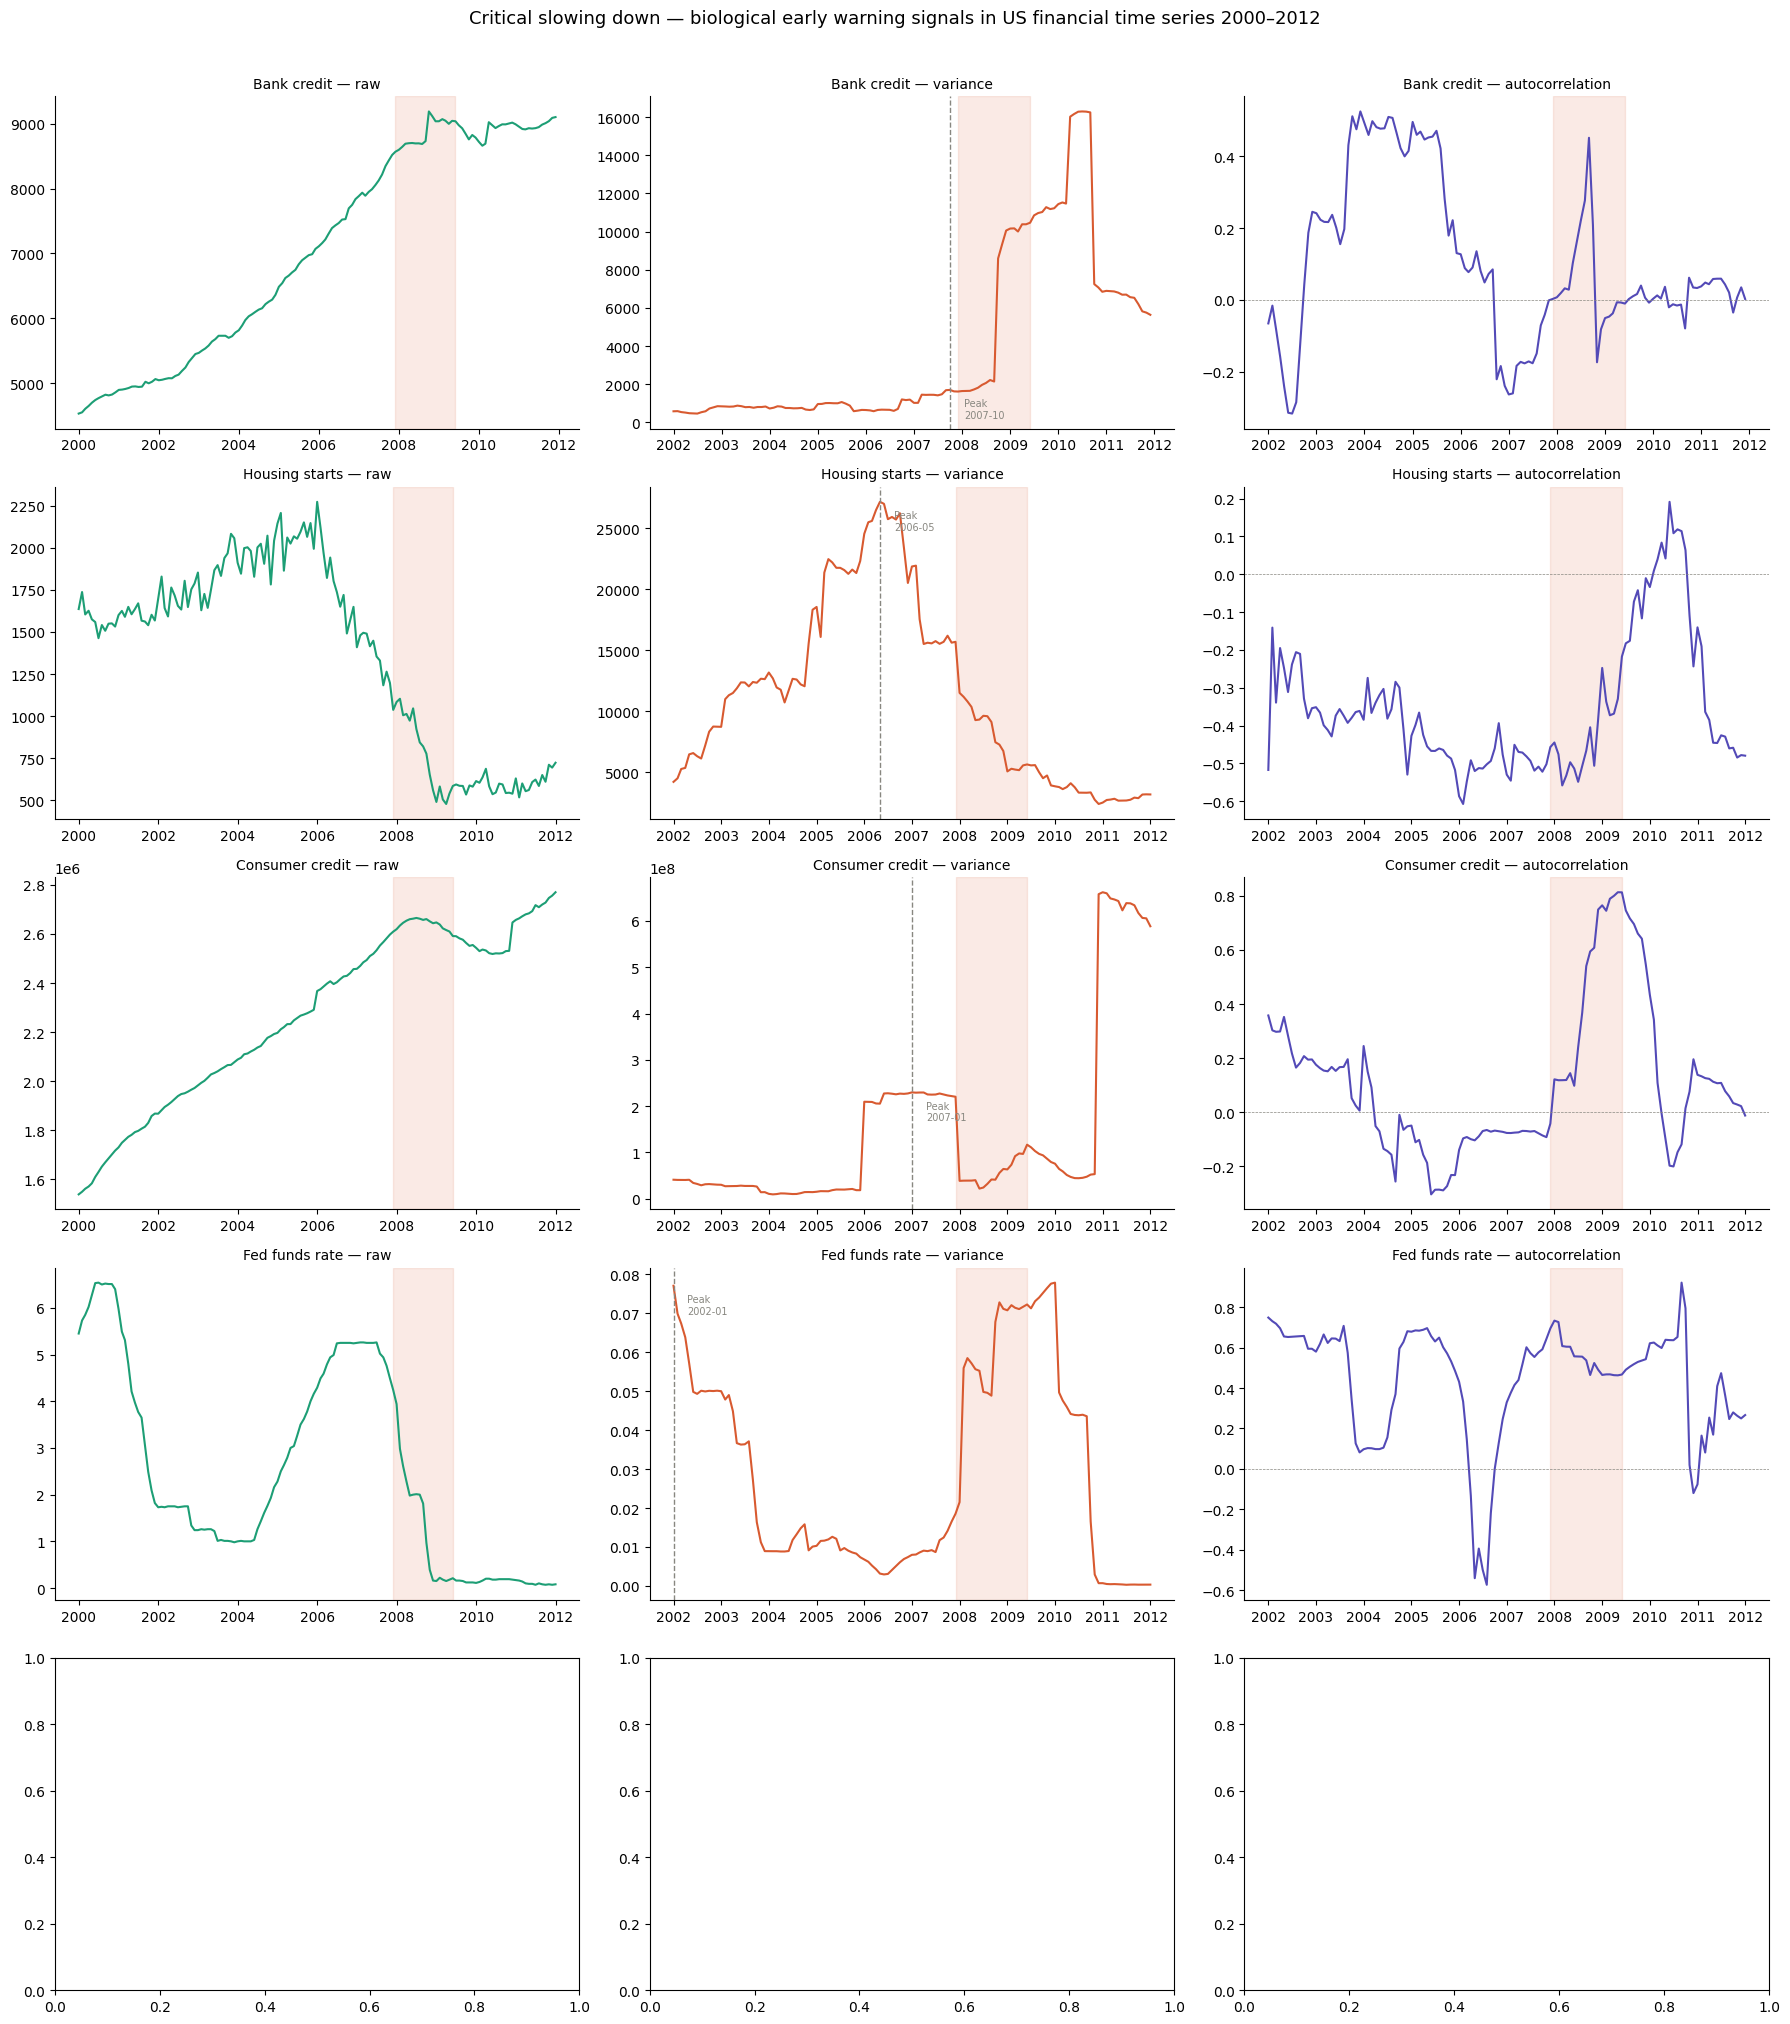

Saved.


In [4]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))

crisis_start = pd.Timestamp('2007-12-01')
crisis_end   = pd.Timestamp('2009-06-01')

for i, (name, res) in enumerate(results.items()):
    monthly = res['monthly']
    var     = res['variance']
    ar1     = res['ar1']

    # Column 1: Raw time series
    ax1 = axes[i, 0]
    ax1.plot(monthly.index, monthly.values, color='#1D9E75', linewidth=1.5)
    ax1.axvspan(crisis_start, crisis_end, alpha=0.12, color='#D85A30')
    ax1.set_title(f'{name} — raw', fontsize=10, fontweight='normal')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Column 2: Rolling variance
    ax2 = axes[i, 1]
    ax2.plot(var.index, var.values, color='#D85A30', linewidth=1.5)
    ax2.axvspan(crisis_start, crisis_end, alpha=0.12, color='#D85A30')
    pre_crisis = var[var.index < crisis_start]
    if len(pre_crisis.dropna()) > 0:
        peak_date = pre_crisis.idxmax()
        peak_val  = pre_crisis.max()
        ax2.axvline(peak_date, color='#888780', linewidth=1, linestyle='--')
        ax2.annotate(f'Peak\n{peak_date.strftime("%Y-%m")}',
                    xy=(peak_date, peak_val),
                    xytext=(10, -20), textcoords='offset points',
                    fontsize=7, color='#888780')
    ax2.set_title(f'{name} — variance', fontsize=10, fontweight='normal')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Column 3: Rolling autocorrelation
    ax3 = axes[i, 2]
    ax3.plot(ar1.index, ar1.values, color='#534AB7', linewidth=1.5)
    ax3.axvspan(crisis_start, crisis_end, alpha=0.12, color='#D85A30')
    ax3.axhline(0, color='#888780', linewidth=0.5, linestyle='--')
    ax3.set_title(f'{name} — autocorrelation', fontsize=10, fontweight='normal')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

plt.suptitle('Critical slowing down — biological early warning signals in US financial time series 2000–2012',
             fontsize=13, fontweight='normal', y=1.01)
plt.tight_layout()
plt.savefig('../data/critical_slowing_down.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [5]:
# Load the processed data saved by notebook 01
# This means you don't need notebook 01 running to continue here
ebi_df = pd.read_csv('../data/processed/ebi_signals.csv')

print("EBI data loaded:")
print(ebi_df.to_string(index=False))

EBI data loaded:
 year      ebi  entropy  top3_concentration  spectral_gap
 2002 2.745725 3.540649            0.224514      0.007874
 2003 2.928857 3.582926            0.182552      0.005263
 2004 2.889034 3.596098            0.196620      0.008511
 2005 3.003392 3.663553            0.180197      0.007752
 2006 2.912006 3.639030            0.199785      0.008065
 2007 2.893572 3.619657            0.200595      0.005190
 2008 2.930440 3.605317            0.187189      0.006849
 2009 2.880815 3.592919            0.198196      0.002915


In [6]:
# Get annual averages of the CSD signals for the years we have BEA data
years_ts = [str(y) for y in range(2002, 2010)]

housing_var_annual = {}
housing_ar1_annual = {}
credit_var_annual  = {}
credit_ar1_annual  = {}

for year in years_ts:
    start = pd.Timestamp(f'{year}-01-01')
    end   = pd.Timestamp(f'{year}-12-31')
    
    hv = results['Housing starts']['variance']
    ha = results['Housing starts']['ar1']
    cv = results['Credit spread']['variance']
    ca = results['Credit spread']['ar1']
    
    housing_var_annual[year] = hv[start:end].mean()
    housing_ar1_annual[year] = ha[start:end].mean()
    credit_var_annual[year]  = cv[start:end].mean()
    credit_ar1_annual[year]  = ca[start:end].mean()

# Merge everything into one master dataframe
master = ebi_df.copy()
master['housing_var'] = [housing_var_annual[str(y)] for y in master['year']]
master['housing_ar1'] = [housing_ar1_annual[str(y)] for y in master['year']]
master['credit_var']  = [credit_var_annual[str(y)]  for y in master['year']]
master['credit_ar1']  = [credit_ar1_annual[str(y)]  for y in master['year']]

print("Master signal table:")
print(master.round(4).to_string(index=False))

KeyError: 'Credit spread'

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

scaler = MinMaxScaler()

# Normalize each component safely (NaNs preserved)
ebi_scaled = scaler.fit_transform(master[['ebi']])
spectral_scaled = scaler.fit_transform(master[['spectral_gap']])
housing_var_scaled = scaler.fit_transform(master[['housing_var']])
credit_var_scaled = scaler.fit_transform(master[['credit_var']])
housing_ar1_scaled = scaler.fit_transform(master[['housing_ar1']])

risk_components = pd.DataFrame({
    'ebi_risk':         1 - ebi_scaled.flatten(),
    'spectral_risk':    1 - spectral_scaled.flatten(),
    'housing_var_risk': housing_var_scaled.flatten(),
    'credit_var_risk':  credit_var_scaled.flatten(),
    'housing_ar1_risk': housing_ar1_scaled.flatten(),
}, index=master.index)

# Compute composite score (ignore NaNs)
master['ecoecon_risk_score'] = risk_components.mean(axis=1, skipna=True)

# Optional: fill any remaining NaNs (if a row is entirely missing)
master['ecoecon_risk_score'] = master['ecoecon_risk_score'].fillna(0)

print("EcoEcon Risk Score by year:")
for _, row in master.iterrows():
    score = row['ecoecon_risk_score']
    
    if pd.isna(score):
        bar = "N/A"
    else:
        bar = '█' * int(score * 30)
    
    print(f"{int(row['year'])}: {score:.3f} {bar}")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 11))

years_int = master['year'].tolist()
crisis_shade = dict(alpha=0.10, color='#D85A30')

# --- Top panel: Risk score over time ---
ax1 = axes[0]
risk = master['ecoecon_risk_score'].tolist()

ax1.fill_between(years_int, risk, 0, alpha=0.15, color='#D85A30')
ax1.plot(years_int, risk, color='#D85A30', linewidth=2.5,
         marker='o', markersize=9, zorder=3, label='EcoEcon Risk Score')

# Danger threshold line
ax1.axhline(0.6, color='#888780', linewidth=1, linestyle='--', label='Alert threshold (0.6)')
ax1.axvspan(2007.5, 2009.5, **crisis_shade)

# Annotate peak risk
peak_year = years_int[risk.index(max(risk))]
ax1.annotate(f'Peak risk: {max(risk):.3f}\n({peak_year})',
             xy=(peak_year, max(risk)),
             xytext=(peak_year - 2, max(risk) - 0.08),
             arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5),
             fontsize=10, color='#D85A30')

ax1.set_ylabel('EcoEcon Risk Score (0 = safe, 1 = crisis)')
ax1.set_title('Unified EcoEcon Risk Score — composite biological early warning signal',
              fontsize=12, fontweight='normal')
ax1.set_ylim(0, 1.05)
ax1.set_xticks(years_int)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Bottom panel: Signal breakdown stacked area ---
ax2 = axes[1]

components = risk_components.values.T
labels = ['EBI risk', 'Spectral risk', 'Housing var risk',
          'Credit var risk', 'Housing AR1 risk']
colors = ['#1D9E75', '#534AB7', '#D85A30', '#BA7517', '#993556']

ax2.stackplot(years_int, components, labels=labels, colors=colors, alpha=0.75)
ax2.axvspan(2007.5, 2009.5, **crisis_shade)
ax2.set_ylabel('Risk contribution by signal')
ax2.set_title('Signal breakdown — what is driving the risk score each year',
              fontsize=12, fontweight='normal')
ax2.set_xticks(years_int)
ax2.legend(fontsize=8, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('EcoEcon — unified biological risk score for the US economy 2002–2009',
             fontsize=14, fontweight='normal')
plt.tight_layout()
plt.savefig('../data/ecoecon_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)

for name, res in results.items():
    safe_name = name.lower().replace(' ', '_')
    
    # Build aligned DataFrame using indices
    df = pd.concat([
        res['monthly'],
        res['variance'],
        res['ar1']
    ], axis=1)

    df.columns = ['value', 'variance', 'ar1']

    # Drop incomplete rows
    df = df.dropna()

    # Reset index so date becomes a column
    df = df.reset_index().rename(columns={'index': 'date'})

    df.to_csv(f'../data/processed/csd_{safe_name}.csv', index=False)

print("All data saved:")
for f in os.listdir('../data/processed'):
    print(f" {f}")

In [ ]:
import subprocess

result = subprocess.run([
    'git', '-C', '..', 'add', '.'
], capture_output=True, text=True)

result2 = subprocess.run([
    'git', '-C', '..', 'commit', '-m', 
    'Phase 2 complete: critical slowing down + unified EcoEcon risk score'
], capture_output=True, text=True)

result3 = subprocess.run([
    'git', '-C', '..', 'push'
], capture_output=True, text=True)

print(result2.stdout or result2.stderr)
print(result3.stdout or result3.stderr)

In [7]:
print(list(results.keys()))

['Bank credit', 'Housing starts', 'Consumer credit', 'Fed funds rate']
